# CASE #04 — Yuzey Segmentasyonu — Colab GPU Egitimi

Bu notebook Google Colab'da (Runtime > Change runtime type > GPU) calistirilmak icin hazirlanmistir.
Repo'yu klonlar/kopyalar, Kaggle'dan Severstal veri setini indirir ve `src/train.py` ile egitimi baslatir.

In [1]:
!nvidia-smi

Thu Sep 17 11:16:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Repo'yu getir
Repo GitHub'a pushlanmadiysa, alternatif olarak Drive'a yukleyip mount edebilirsiniz.

In [2]:
REPO_URL = "https://github.com/nursimaonerr/surface-defect-segmentation.git"
!git clone $REPO_URL project
%cd project

Cloning into 'project'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 34 (delta 6), reused 26 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 17.10 KiB | 5.70 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/project


## 2. Bagimliliklar

In [3]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.8 MB/s eta 0:00:00


## 3. Kaggle API ile veri indirme
Kaggle hesabinizdan **Settings → API → Create New Token** ile aldiginiz token'i asagida girin (Colab Secrets kullanmak isterseniz `KAGGLE_TOKEN` adiyla ekleyip `from google.colab import userdata; userdata.get('KAGGLE_TOKEN')` ile okuyabilirsiniz).

In [4]:
from google.colab import userdata
import os

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
kaggle_token = userdata.get('KAGGLE_TOKEN')  # Colab Secrets'a onceden eklenmis olmali
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(kaggle_token)
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)

In [5]:
!bash scripts/download_data.sh

100% 1.57G/1.57G [01:30<00:00, 18.5MB/s]

Veri hazir: /content/project/data/raw
sample_submission.csv  test_images  train.csv  train_images


## 4. Egitim
Colab GPU (T4/A100) icin daha buyuk batch-size ve tam epoch sayisi kullanilabilir.

In [6]:
!python -m src.train \
  --arch unet \
  --encoder resnet34 \
  --epochs 40 \
  --batch-size 16 \
  --lr 1e-4 \
  --checkpoint-dir checkpoints

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
config.json: 100% 156/156 [00:00<00:00, 606kB/s]

model.safetensors: downloading bytes:  88% 76.6M/87.3M [00:01<00:00, 84.8MB/s, 5.97MB/s  ]
model.safetensors: downloading bytes: 100% 80.6M/80.6M [00:01<00:00, 42.9MB/s, 7.50MB/s  ]
model.safetensors: reconstructing file: 100% 87.3M/87.3M [00:01<00:00, 46.5MB/s, 8.31MB/s  ]
/content/project/src/train.py:70: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScale

## 5. Checkpoint'i Drive'a kaydet

In [9]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/case4_checkpoints
!cp checkpoints/best.pth /content/drive/MyDrive/case4_checkpoints/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 6. Ornek cikarim ve gorsellestirme

Kaydedildi: sample_overlay.png


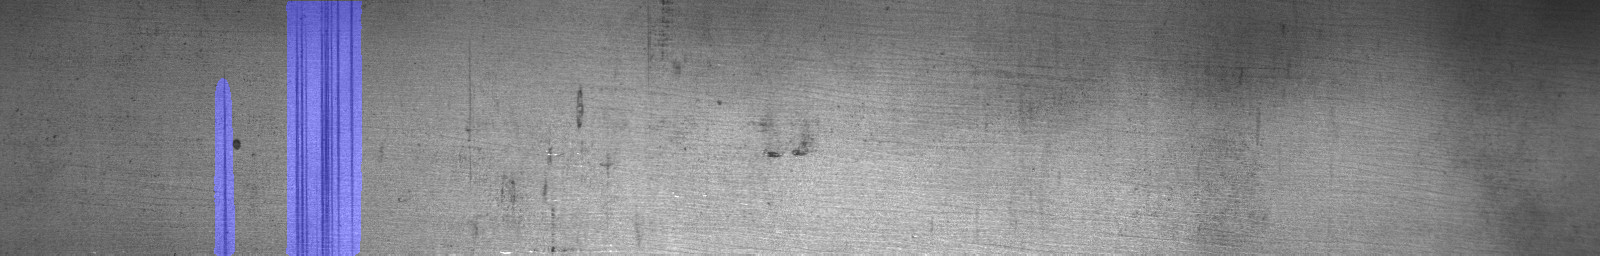

In [8]:
import glob
sample = glob.glob('data/raw/train_images/*.jpg')[0]
!python -m src.infer --checkpoint checkpoints/best.pth --image "$sample" --out sample_overlay.png
from IPython.display import Image
Image('sample_overlay.png')